# **BUSINESS UNDERSTANDING**

## Business Overview

Not all customers contribute equally to revenue. Some purchase frequently and spend more, while others buy occasionally or may disengage over time. Understanding these differences is crucial for improving marketing effectiveness, strengthening customer relationships, and increasing overall profitability. A data-driven approach to customer segmentation enables businesses to identify high-value customers, detect those at risk of churn, and tailor engagement strategies accordingly.

## Problem Statement

In most retail businesses, customers are often treated as a single group in marketing and engagement strategies, despite exhibiting different purchasing behaviors. This makes it challenging to:

* Identify customers who contribute most to revenue,
* Detect customers at risk of disengagement or churn, and
* Allocate marketing resources effectively.

Segmenting customers based on purchasing behavior allows businesses to move beyond a one-size-fits-all approach. Using RFM analysis (Recency, Frequency, Monetary) and clustering techniques, organizations can identify premium & loyal customers, detect at-risk customers, and design targeted marketing and retention strategies. This approach provides actionable insights that support targeted campaigns, optimized resource allocation, and improved overall business performance.

## Project Objectives

* Prepare and transform customer transaction data by cleaning the dataset and creating key behavioral features.
* Apply the K-Means clustering technique to segment customers based on similarities in their purchasing behavior
* Visualize and interpret the clusters to understand behavioral patterns..
* Detect customers who contribute significantly to revenue and customers who may be at risk of disengagement/churn.
* Generate actionable insights that support targeted marketing strategies, improved customer retention, and better business decision-making.

# **DATA UNDERSTANDING**

* The dataset used is the Online Retail Dataset from the UCI, which contains transactional records that capture customer purchasing behavior over time. It is provided in Excel format and represents real-world e-commerce transactions.

In [1]:
# Load the Data
import pandas as pd
df=pd.read_excel("data/Online Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


**Dataset Features**
1. **InvoiceNo** - identifier for each transaction
2. **StockCode** - Unique product code
3. **Description** - The description of the product purchased
4. **Quantity** - The number of products purchased in a single transaction.
5. **InvoiceDate** - The date and time of the transaction
6. **UnitPrice** - The price of a single unit of the product.
7. **CustomerID** - Identifier for each customer
8. **Country** - The country where the customer is located.
   
**Target Variable**
* Since this is an unsupervised learning problem, there is no target variable, and the objective is to group customers based on purchasing behavior
  
**Purchasing behavior to be analysed(RFM Features)**
1. **Recency** - How recently a customer bought something
2. **Frequency** - How often a customer buys
3. **Monetary** - Total amount of money a customer spends

In [2]:
# import libraries
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["LOKY_MAX_CPU_COUNT"] = "4"
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [3]:
# Basic info of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


* The dataset contains a mix of **categorical**(InvoiceNo, StockCode, Description, Country), **numerical**(Quantity as integer, UnitPrice & CustomerID as float) and **temporal variable**(InvoiceDate as datetime)

In [4]:
# Dataset Size
df.shape

(541909, 8)

In [5]:
# statistical summary of the dataset
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


* Negative values in Quantity and UnitPrice indicate returned/refunded transactions, where negative quantities are used to reverse earlier positive transactions.

In [6]:
# Check for duplicates
df.duplicated().sum()

5268

In [7]:
# Check for Null values
df.isnull().sum().sort_values(ascending=False)

CustomerID     135080
Description      1454
InvoiceNo           0
StockCode           0
Quantity            0
InvoiceDate         0
UnitPrice           0
Country             0
dtype: int64

# **DATA PREPARATION**

## Data Cleaning

In [8]:
# Drop duplicates
df = df.drop_duplicates()
df.duplicated().sum()

0

In [9]:
# Handle Missing values 
df = df.dropna(subset=["CustomerID"])    
df = df.dropna(subset=["Description"])
df.isna().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [10]:
# Remove Negative transactions(returns/refunds) in Quantity	& UnitPrice columns
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,392692.000000,392692,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892480,3.125914,15287.843865
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000
std,180.492832,NaN,22.241836,1713.539549


## Feature Creation

In [11]:
# Create a new column "TotalPrice" for the total amount a customer spends (Monetary)
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

* The RFM table is then created, where Recency is calculated from the InvoiceDate column, Frequency from the InvoiceNo column, and Monetary value from the TotalPrice column.

In [12]:
# RFM Table 
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,    # Recency
    "InvoiceNo": "nunique",                                      # Frequency
    "TotalPrice": "sum"                                          # Monetary
})

rfm.columns = ["Recency", "Frequency", "Monetary"]
rfm.head(7)

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40
12352.0,36,8,2506.04
12353.0,204,1,89.00


In [13]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


**RFM Table**
* Recency ranges from 1 to 374 days, with a median of 51 days
* Frequency varies widely from 1 to 209 transactions, with a median of 2 transactions
* Monetary also varies widely from 3.75 to 280,206(currency units), with a median of 668.57 


* The RFM table summary statistics indicate the presence of extreme values, particularly in the Frequency and Monetary variables. A small number of customers exhibit very high purchase frequency and spending(monetary) levels compared to the majority of customers. These observations likely represent genuine high-value customers, and removing them could result in the loss of important business information. Therefore, to ensure that these large values do not excessively influence the clustering process, feature scaling will be applied before modeling.

## Feature Scaling

In [14]:
# select only RFM features
rfm_features = rfm[["Recency", "Frequency", "Monetary"]]

# Initialize scaler
scaler = StandardScaler()

# Fit & transform
rfm_scaled = scaler.fit_transform(rfm_features)

# **MODELING**

## Elbow Method

* To find the optimal number of clusters (K)

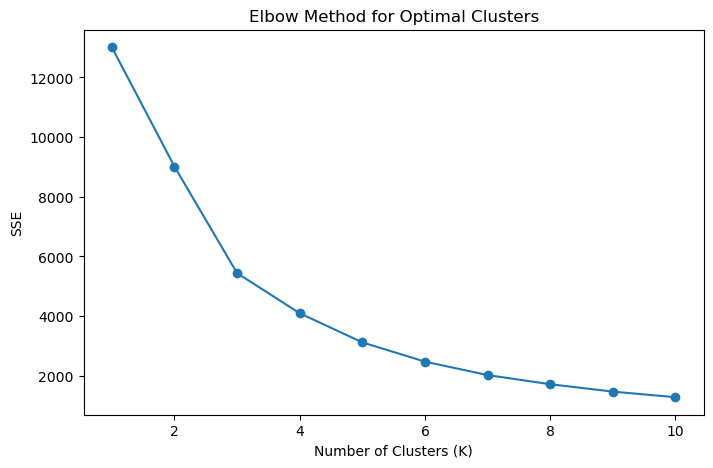

In [15]:
# Store SSE values
sse = []

# Test cluster numbers from 1 to 10
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42,n_init=10)
    kmeans.fit(rfm_scaled)
    sse.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(8,5))
plt.plot(K_range, sse, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("SSE")
plt.title("Elbow Method for Optimal Clusters")
plt.show()

* The elbow point appears around K = 3 and K = 4, indicating that the optimal number of clusters lies within this range. The Silhouette Method will be applied to further evaluate the most suitable K value.

## Silhouette Method 

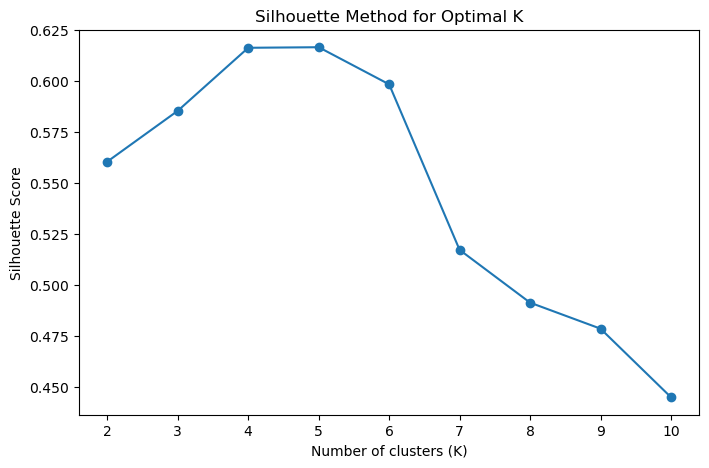

In [16]:
# Test K values from 2 to 10
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(rfm_scaled)

    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)

# Plot silhouette scores
plt.figure(figsize=(8,5))
plt.plot(K_range, silhouette_scores, marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method for Optimal K")
plt.show()

* Silhouette Score measures clustering quality by evaluating how well data points fit within their assigned clusters compared to others. From the plot, the peak score occurs at K = 4, suggesting that the data is best segmented into four clusters

## K-Means Clustering 

* To Group customers into clusters.

In [17]:
# Instatiate K-Means Clustering
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

# Assign clusters to customers
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

# View the table 
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


In [18]:
# Check the clusters
rfm["Cluster"].value_counts()

Cluster
0    3054
1    1067
3     204
2      13
Name: count, dtype: int64

* From the table each customer is assigned a cluster number eg (0, 1, 2, 3).

## Give The Clusters Meaningful Names

* To interpret the clusters, the cluster centroids are examined. A centroid represents the average/mean values of Recency, Frequency, and Monetary for customers within each cluster. These values reveal the purchasing behaviour of each group and help assign meaningful business-oriented names to the clusters.

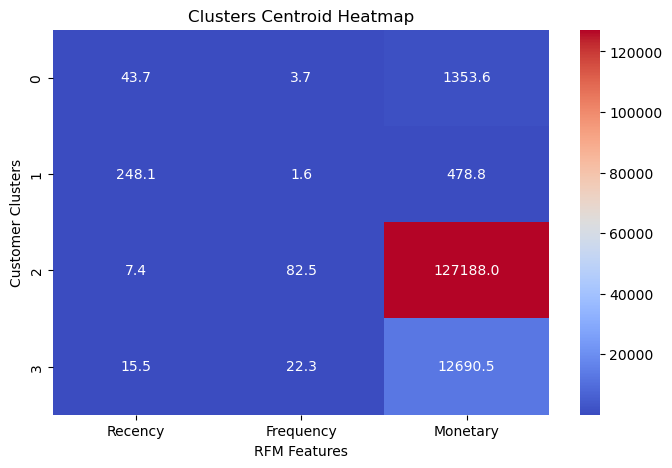

In [19]:
# Average RFM values per segment
centroids = rfm.groupby("Cluster")[["Recency","Frequency","Monetary"]].mean()

plt.figure(figsize=(8,5))
sns.heatmap(centroids, annot=True, cmap="coolwarm", fmt=".1f")

plt.title("Clusters Centroid Heatmap")
plt.ylabel("Customer Clusters")
plt.xlabel("RFM Features")

plt.show()

In [20]:
centroids.round(2)

,Recency,Frequency,Monetary
Cluster,,,
0,43.70,3.68,1353.63
1,248.08,1.55,478.85
2,7.38,82.54,127187.96
3,15.50,22.33,12690.50


* Cluster examination following the RFM framework:

1. Lower Recency values indicate that the customer purchased more recently and is therefore more likely to be active, while higher Recency values indicate longer periods since the last purchase.
2. Higher Frequency values  indicate frequent purchasing, while lower values suggest less frequent interaction.
3. Higher Monetary values indicate customers who spend more, whereas lower values represent lower spending levels.
   
* By analyzing the RFM centroid values, each cluster can be examined and assigned meaningful names.


* Cluster 0 – Promising Customers: These customers have a relatively long time since their last purchase(high recency=43.70) but demonstrate high spending potential(monetary=1,353.63).
* Cluster 1 – Churned/At Risk Customers: These customers exhibit a very long period since their last purchase(highest recency=248.08 & lowest frequency=1.55 ), and low spending behavior(lowest monetary=478.85)
* Cluster 2 – VIP Customers: Show extremely recent purchasing behavior(lowest receny=7.38), the highest frequency(frequency=82.54), and the highest spending(highest Monetary=127,187.96)
* Cluster 3 – Loyal Customers: shows recent engagement(low recency=15.50) with consistent purchasing(high frequency=22.33) and high spending behavior(high monetary=12,690.50)

In [21]:
# Assigning the Clusters Meaningful Names
segment_map = { 
    0: "Promising Customers",          
    1: "Churned/At-Risk Customers",    
    2: "VIP Customers",                
    3: "Loyal Customers"               
}
rfm["Segment"] = rfm["Cluster"].map(segment_map)
rfm[["Recency", "Frequency", "Monetary", "Cluster", "Segment"]].head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,326,1,77183.60,3,Loyal Customers
12347.0,2,7,4310.00,0,Promising Customers
12348.0,75,4,1797.24,0,Promising Customers
12349.0,19,1,1757.55,0,Promising Customers
12350.0,310,1,334.40,1,Churned/At-Risk Customers


## Cluster Visualization with PCA

* Principal Component Analysis (PCA) is applied to reduce data dimensionality to two and three components, simplifying cluster visualization and highlighting the separation between customer segments

### 3-D Visual

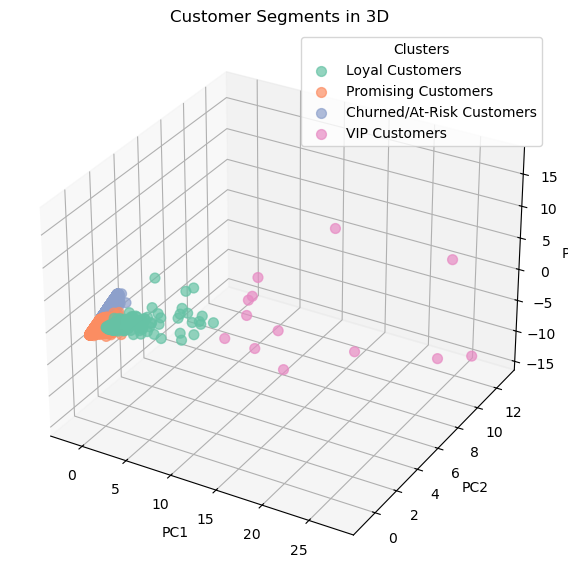

In [22]:
from mpl_toolkits.mplot3d import Axes3D

# PCA with 3 components
pca_3d = PCA(n_components=3)
rfm_pca_3d = pca_3d.fit_transform(rfm_scaled)

# Create DataFrame
rfm_pca_3d_df = pd.DataFrame(rfm_pca_3d, columns=["PC1", "PC2", "PC3"])
rfm_pca_3d_df["Segment"] = rfm["Segment"].values

# 3D Plot
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

# Maps each cluster to a color
segments = rfm_pca_3d_df["Segment"].unique()
colors = sns.color_palette("Set2", len(segments))

for seg, color in zip(segments, colors):
    subset = rfm_pca_3d_df[rfm_pca_3d_df["Segment"] == seg]
    ax.scatter(
        subset["PC1"], subset["PC2"], subset["PC3"],
        label=seg,
        color=color,
        s=50, alpha=0.7
    )

ax.set_title("Customer Segments in 3D")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.legend(title="Clusters")
plt.show()

### 2-D Visual

C:\Users\ADMIN\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


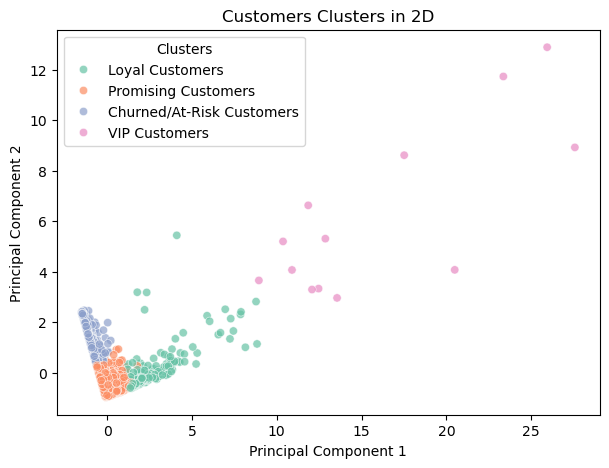

In [23]:
# Initialize PCA
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)

# Create a DataFrame for plotting
rfm_pca_df = pd.DataFrame(rfm_pca, columns=["PC1", "PC2"])
rfm_pca_df["Segment"] = rfm["Segment"].values

plt.figure(figsize=(7,5))
sns.scatterplot(
    x="PC1", y="PC2",
    hue="Segment",
    data=rfm_pca_df,
    palette="Set2",
    alpha=0.7
)
plt.title("Customers Clusters in 2D")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Clusters")
plt.show()

* The VIP customers cluster appears relatively dispersed (high intra-cluster distances), indicating some variability in purchasing behavior. While these customers share strong spending characteristics, subtle differences exist in their purchase patterns. Given their critical contribution to revenue, a heatmap of the VIP cluster centroid will be used to uncover the distinct patterns within the segment and guide targeted marketing strategies.
* In contrast, the other clusters(Loyal, Promising, and Churned/At-Risk customers) are tightly grouped (low intra-cluster distances), suggesting these groups share similar behavioral patterns.

## Further Segmentation of VIP Group

In [24]:
print(rfm.columns)

Index(['Recency', 'Frequency', 'Monetary', 'Cluster', 'Segment'], dtype='object')


In [25]:
# Select VIP customers
vip_df = rfm[rfm["Segment"] == "VIP Customers"].copy()

# Select RFM features
X = vip_df[["Recency", "Frequency", "Monetary"]]

In [26]:
#  Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

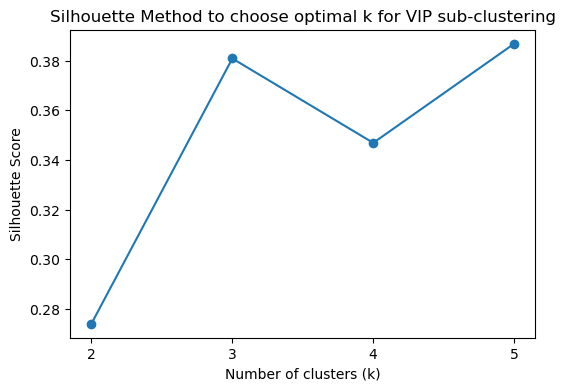

In [27]:

sil_scores = []
k_values = range(2, 6)  # try 2 to 5 clusters
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

# Plot Silhouette scores
plt.figure(figsize=(6,4))
plt.plot(k_values, sil_scores, marker='o')
plt.xticks(k_values)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method to choose optimal k for VIP sub-clustering")
plt.show()

In [28]:
#  Apply K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42)  # with 3 clusters
vip_df["VIP_Subclusters"] = kmeans.fit_predict(X_scaled)


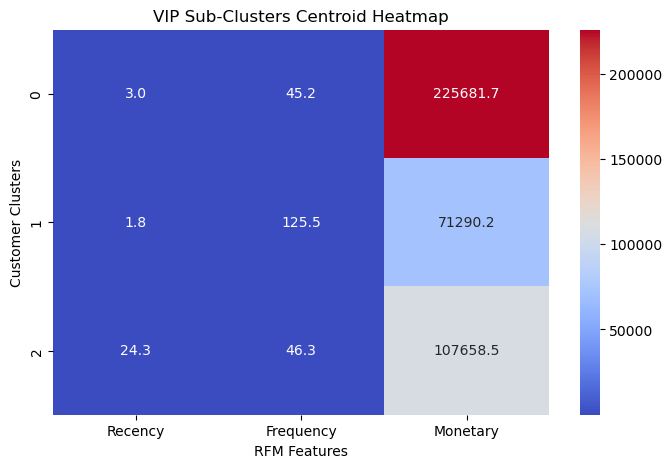

In [29]:
# Average RFM values per segment
# centroids = rfm.groupby("Cluster")[["Recency","Frequency","Monetary"]].mean()
vip_summary = vip_df.groupby("VIP_Subclusters")[["Recency", "Frequency", "Monetary"]].mean()

plt.figure(figsize=(8,5))
sns.heatmap(vip_summary, annot=True, cmap="coolwarm", fmt=".1f")

plt.title("VIP Sub-Clusters Centroid Heatmap")
plt.ylabel("Customer Clusters")
plt.xlabel("RFM Features")

plt.show()

In [30]:
# Sub-cluster center 
vip_summary = vip_df.groupby("VIP_Subclusters")[["Recency", "Frequency", "Monetary"]].mean().round(2)
print(vip_summary)

                 Recency  Frequency   Monetary
VIP_Subclusters                               
0                   3.00      45.25  225681.65
1                   1.83     125.50   71290.24
2                  24.33      46.33  107658.48


In [31]:
#  Assign the clusters meaningful names
subcluster_names = {
    0: "Premium VIPs",          
    1: "Loyal Frequent VIPs",   
    2: "At-Risk VIPs"           
}

vip_df["VIP_Subclusters_Name"] = vip_df["VIP_Subclusters"].map(subcluster_names)


In [32]:
vip_df.head()

,Recency,Frequency,Monetary,Cluster,Segment,VIP_Subclusters,VIP_Subclusters_Name
CustomerID,,,,,,,
12415.0,24,21,124914.53,2,VIP Customers,2,At-Risk VIPs
12748.0,1,209,33053.19,2,VIP Customers,1,Loyal Frequent VIPs
13089.0,3,97,58762.08,2,VIP Customers,1,Loyal Frequent VIPs
14156.0,10,55,117210.08,2,VIP Customers,2,At-Risk VIPs
14646.0,2,73,280206.02,2,VIP Customers,0,Premium VIPs


### VIP Sub-Cluster Behavioral Insights

* VIP Sub-Cluster 0 (Premium VIPs): Shows extremely high spending (monetary=225,681.65), and recent purchasing behavior (recency=3.00).
* VIP Sub-Cluster 1 (Loyal Frequent VIPs): Exhibits the most recent purchases (recency=1.83), and extremely high purchasing frequency (frequency=125.50)
* VIP Sub-Cluster 2 (At-Risk VIPs): VIPs that spend highly(monetary=107658.48) but haven't purchased recently(recency = 24.33)

In [33]:

# Create Final Customer Segmentation Dataset that will be used in Deployment & Tableau dashboard



# The Main RFM Segmentation Data already contain Recency, Frequency, Monetary, Cluster, Segment
rfm_main = rfm.reset_index()[[
    "CustomerID",
    "Recency",
    "Frequency",
    "Monetary",
    "Segment"
]]


#  The Second df VIP Subsegment data contain Names for each VIP customers
vip_sub = vip_df.reset_index()[[
    "CustomerID",
    "VIP_Subclusters_Name"
]]

# Rename VIP_Subclusters_Name column to VIP_Subsegment
vip_sub = vip_sub.rename(columns={
    "VIP_Subclusters_Name": "VIP_Subsegment"
})


# Merge the 2 dfs
final_df = rfm_main.merge(
    vip_sub,
    on="CustomerID",
    how="left"                
)

final_df.head()

,CustomerID,Recency,Frequency,Monetary,Segment,VIP_Subsegment
0,12346.0,326,1,77183.60,Loyal Customers,NaN
1,12347.0,2,7,4310.00,Promising Customers,NaN
2,12348.0,75,4,1797.24,Promising Customers,NaN
3,12349.0,19,1,1757.55,Promising Customers,NaN
4,12350.0,310,1,334.40,Churned/At-Risk Customers,NaN


In [34]:
# Clean segment names by removing the word "Customers" to make labels cleaner/shoter
final_df["Segment"] = final_df["Segment"].str.replace(" Customers", "", regex=False)


# Esures customer ID is interger not float to prevents API lookup issues
final_df["CustomerID"] = final_df["CustomerID"].astype(int)

# Previw Final Dataset
final_df.head()

,CustomerID,Recency,Frequency,Monetary,Segment,VIP_Subsegment
0,12346,326,1,77183.60,Loyal,NaN
1,12347,2,7,4310.00,Promising,NaN
2,12348,75,4,1797.24,Promising,NaN
3,12349,19,1,1757.55,Promising,NaN
4,12350,310,1,334.40,Churned/At-Risk,NaN


* Missing values (NaN) in the VIP_Subsegment column represent customers who are not part of the VIP segment. These values are intentionally left as NaN so that Tableau automatically excludes them during VIP subsegment visualizations, to prevent the creation of misleading categories

In [35]:
# Save Final Dataset
final_df.to_csv("rfm_customer_segments.csv", index=False)

print("Final dataset saved as: rfm_customer_segments.csv")


Final dataset saved as: rfm_customer_segments.csv


In [36]:
final_df.shape

(4338, 6)

* Each row in the final dataset now represents a unique customer rather than an individual transaction. In plain terms Instead of having many rows for one customer who made multiple transactions now it is sumarized

# BUSINESS INSIGHTS & MARKETING STRATEGIES

## Segment Distribution

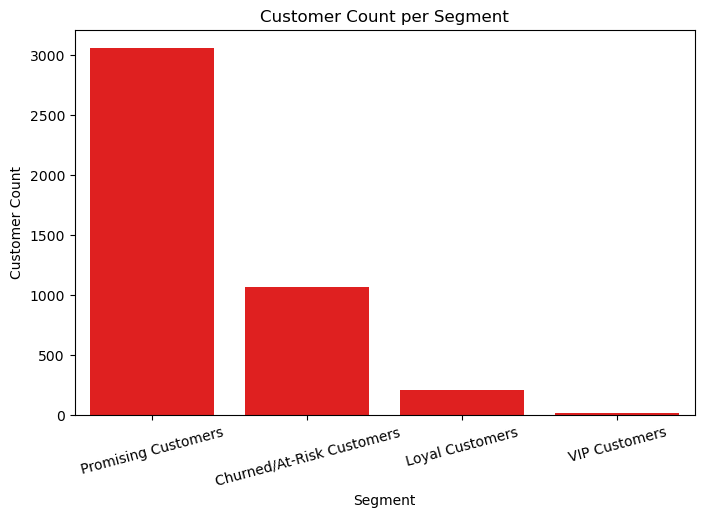

In [37]:
segment_counts = rfm["Segment"].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=segment_counts.index, y=segment_counts.values, color="red") 
plt.title("Customer Count per Segment")
plt.ylabel("Customer Count")
plt.xticks(rotation=15)
plt.show()

## Total Revenue Per Segment

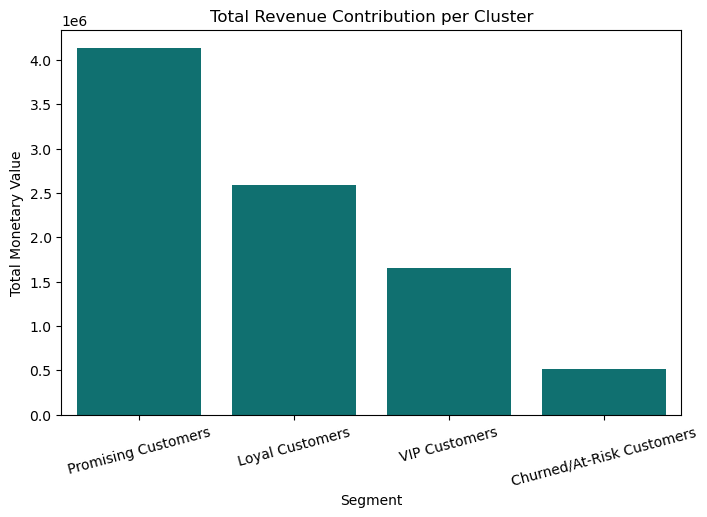

In [38]:
# Sum of Monetary per segment
rfm_monetary = rfm.groupby("Segment")["Monetary"].sum().sort_values(ascending=False)

# Plot
plt.figure(figsize=(8,5))
sns.barplot(x=rfm_monetary.index, y=rfm_monetary.values, color="teal")
plt.title("Total Revenue Contribution per Cluster")
plt.ylabel("Total Monetary Value")
plt.xticks(rotation=15)
plt.show()

1. Promising Customers represent the largest segment and generate the highest revenue. Encouraging repeat purchases through targeted offers, product recommendations and personalized engagement could help convert them into loyal customers and maximize long-term value.
2. At-Risk / Churned Customers are many but contribute the least revenue, targeted offers and reactivation messages can be leveraged to reduce churn and re-engage these individuals. Ignore if unresponsive to save cost.
3. Loyal Customers are fewer in number but already actively engaged and contribute highly to revenue. Implementing loyalty programs and exclusive rewards can help retain them and potentially move them into the VIP segment.
4. VIP Customers, though small in number they show significant contribution to revenue.

## VIP Sub-Cluster Distribution

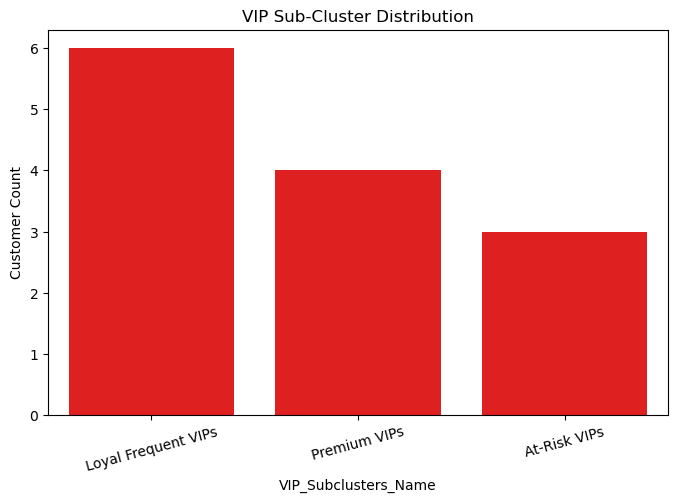

In [39]:
vip_counts = vip_df["VIP_Subclusters_Name"].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=vip_counts.index, y=vip_counts.values, color="red")
plt.title("VIP Sub-Cluster Distribution")
plt.ylabel("Customer Count")
plt.xticks(rotation=15)
plt.show()

## Total Revenue Contribution by VIP Sub-Cluster

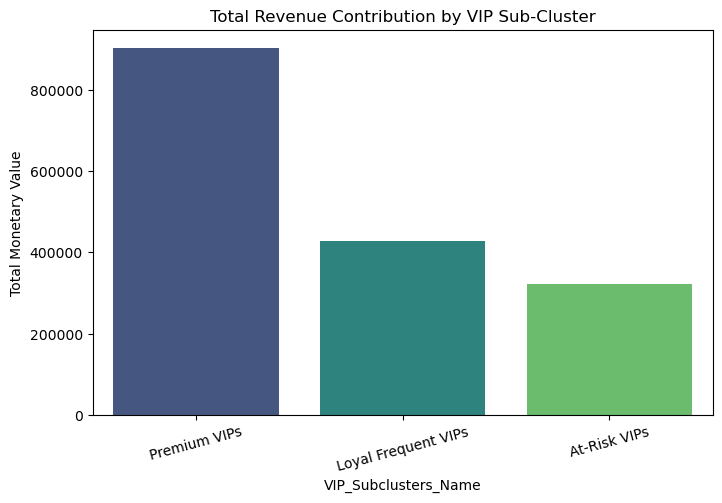

In [40]:
vip_monetary = vip_df.groupby("VIP_Subclusters_Name")["Monetary"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=vip_monetary.index, y=vip_monetary.values, palette="viridis", hue=vip_monetary.index)
plt.title("Total Revenue Contribution by VIP Sub-Cluster")
plt.ylabel("Total Monetary Value")
plt.xticks(rotation=15)
plt.show()


1. Premium VIPs: Contribute the most to revenue and should be retained through exclusive privileges, such as early access to products, personalized offers, and VIP-only rewards programs.
2. Loyal Frequent VIPs: Although more numerous, they contribute less revenue than Premium VIPs. They should be encouraged to spend more through strategies like recommending premium products, offering “spend more – get more” deals, rewarding high spending behavior and personalized offers based on past purchasing behavior to suggest products they are likely to buy.
3. At-Risk VIPs: A small group with high potential but low engagement require urgent re-engagement plans such as targeted discounts, personalized messages, and tailored offers to prevent the loss of these valuable customers.

# CONCLUSION

* The business should prioritize customer retention and strategically advance customers along the value ladder — converting Promising customers into Loyal, and Loyal customers into VIPs. Efforts should also focus on maximizing revenue from VIP and Loyal customers, rather than relying primarily on the larger base of lower-spending Promising customers for revenue.